In [1]:
from datasets import load_dataset
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

dataset = load_dataset("Tobi-Bueck/customer-support-tickets")
df = dataset["train"].to_pandas()

/Users/kylebeedon/opt/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Initial Text Cleaning

In [2]:
# ── Translate all German tickets ──────────────────────────────
from deep_translator import GoogleTranslator
from tqdm import tqdm
import time

def translate_to_english(text):
    for attempt in range(3):  # retry up to 3 times
        try:
            return GoogleTranslator(source="de", target="en").translate(str(text)[:4999])
        except Exception:
            time.sleep(2)  # wait 2 seconds before retrying
    return text  # fall back to original after 3 failed attempts

german_mask = df["language"] == "de"
print(f"Translating {german_mask.sum()} German tickets...")

df.loc[german_mask, "subject"] = [
    translate_to_english(t) for t in tqdm(df.loc[german_mask, "subject"], desc="Subjects")
]
df.loc[german_mask, "body"] = [
    translate_to_english(t) for t in tqdm(df.loc[german_mask, "body"], desc="Bodies")
]

print("Translation complete.")

# ── Save translated dataframe so you don't have to re-run ─────
df.to_csv("df_translated.csv", index=False)
print("Saved to df_translated.csv")

Translating 33504 German tickets...


Bodies: 100%|███████████████████████████| 33504/33504 [8:51:24<00:00,  1.05it/s]


Translation complete.
Saved to df_translated.csv


In [24]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"^(dear\s+)?(customer\s+(support|service)\s*(team)?|support\s*team)[\s,:\-]*", "", text)
    text = re.sub(r"^(hello|hi|greetings)[\s,:\-]*", "", text)
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"(best regards|kind regards|sincerely).*", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [25]:
from deep_translator import GoogleTranslator
from tqdm import tqdm

def translate_to_english(text):
    try:
        # Google Translator has a 5000 char limit per call
        return GoogleTranslator(source="de", target="en").translate(str(text)[:4999])
    except Exception:
        return text  # fall back to original if translation fails

german_mask = df["language"] == "de"
print(f"Translating {german_mask.sum()} German tickets...")

df.loc[german_mask, "subject"] = [
    translate_to_english(t) for t in tqdm(df.loc[german_mask, "subject"], desc="Subjects")
]
df.loc[german_mask, "body"] = [
    translate_to_english(t) for t in tqdm(df.loc[german_mask, "body"], desc="Bodies")
]

print("Translation complete.")

Translating 33504 German tickets...


Subjects:   1%|▏                | 324/33504 [106:31:08<10908:19:32, 1183.54s/it]


KeyboardInterrupt: 

In [ ]:
df["body"] = df["body"].astype(str).apply(clean_text)
df["subject"] = df["subject"].astype(str).apply(clean_text)
df["text"] = df["subject"] + " " + df["body"]
df["version"] = df["version"].fillna("unknown").astype(str)

tag_cols = [f"tag_{i}" for i in range(1, 9)]
df["all_tags"] = df[tag_cols].fillna("").agg(" ".join, axis=1)

print(df["priority"].value_counts())

## Train test split


In [19]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["priority"])
y = df["priority"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train size: {len(X_train)} | Test size: {len(X_test)}")

Tier 1 label distribution:
priority_tier1
high      23839
medium    23378
low       14548
Name: count, dtype: int64


In [20]:
df_tier1 = df.copy()
df_tier1["priority_tier1"] = df_tier1["priority"].replace({"critical": "high"})

X_t1 = df_tier1.drop(columns=["priority", "priority_tier1"])
y_t1 = df_tier1["priority_tier1"]

X_t1_train, X_t1_test, y_t1_train, y_t1_test = train_test_split(
    X_t1, y_t1, test_size=0.2, stratify=y_t1, random_state=42
)

print("Tier 1 label distribution:")
print(y_t1.value_counts())

# 1st model

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# language is kept in Tier 1 — it is a legitimate signal for low/medium/high
text_col = "text"
cat_cols_t1 = ["type", "version", "all_tags", "language"]

preprocessor_t1 = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            max_features=80000,
            ngram_range=(1, 3),
            stop_words="english",
            sublinear_tf=True,
            max_df=0.85,
            norm=None,
            min_df=5
        ), text_col),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_t1)
    ]
)

In [7]:
# ── Cell 4: Tier 1 pipeline + fit ────────────────────────────
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

pipeline_tier1 = Pipeline([
    ("preprocessing", preprocessor_t1),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        n_jobs=-1
    ))
])

pipeline_tier1.fit(X_t1_train, y_t1_train)
print("Tier 1 training complete.")

/Users/kylebeedon/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Tier 1 training complete.


In [8]:
# ── Cell 5: Tier 1 evaluation ─────────────────────────────────
from sklearn.metrics import classification_report, roc_auc_score

y_t1_pred = pipeline_tier1.predict(X_t1_test)

print("=== Tier 1 Classification Report ===")
print(classification_report(y_t1_test, y_t1_pred))

auc_t1 = roc_auc_score(
    y_t1_test,
    pipeline_tier1.predict_proba(X_t1_test),
    multi_class="ovr",
    average=None,
    labels=pipeline_tier1.classes_
)

print("\nPer-class AUC (Tier 1):")
for cls, score in zip(pipeline_tier1.classes_, auc_t1):
    print(f"  {cls:>10}: {score:.3f}")

=== Tier 1 Classification Report ===
              precision    recall  f1-score   support

        high       0.78      0.79      0.78      4768
         low       0.76      0.73      0.74      2910
      medium       0.75      0.75      0.75      4675

    accuracy                           0.76     12353
   macro avg       0.76      0.76      0.76     12353
weighted avg       0.76      0.76      0.76     12353

Per-class AUC (Tier 1):
        high: 0.901
         low: 0.905
      medium: 0.878


In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

t1_classes = pipeline_tier1.classes_
y_t1_bin = label_binarize(y_t1_test, classes=t1_classes)
y_t1_probs = pipeline_tier1.predict_proba(X_t1_test)

plt.figure(figsize=(8, 6))
colors = ["steelblue", "darkorange", "seagreen"]

for i, (cls, color) in enumerate(zip(t1_classes, colors)):
    fpr, tpr, _ = roc_curve(y_t1_bin[:, i], y_t1_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{cls} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tier 1 ROC Curve (OvR) — low / medium / high")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

# 2nd Model

In [9]:
from deep_translator import GoogleTranslator
from tqdm import tqdm

def translate_to_english(text):
    try:
        return GoogleTranslator(source="de", target="en").translate(text[:4999])
    except:
        return text  # fall back to original if translation fails

# Translate critical tickets to English
df_critical = df[df["priority"] == "critical"].copy()
df_high = df[df["priority"] == "high"].copy()

print("Translating critical ticket text fields (this will take a few minutes)...")
df_critical["text"] = [
    translate_to_english(t) for t in tqdm(df_critical["text"])
]

# Rebuild Tier 2 with translated critical + all high tickets
df_tier2 = pd.concat([df_critical, df_high], ignore_index=True)
df_tier2["version"] = df_tier2["version"].fillna("unknown").astype(str)
df_tier2["all_tags"] = df_tier2[[f"tag_{i}" for i in range(1, 9)]].fillna("").agg(" ".join, axis=1)

print("Tier 2 label distribution (translated):")
print(df_tier2["priority"].value_counts())

Translating critical ticket text fields (this will take a few minutes)...


100%|███████████████████████████████████████| 1914/1914 [20:48<00:00,  1.53it/s]

Tier 2 label distribution (translated):
priority
high        21925
critical     1914
Name: count, dtype: int64


In [11]:
# ── Cell 7 UPDATED: Tier 2 train/test split ───────────────────────────────────
X_t2 = df_tier2.drop(columns=["priority"])
y_t2 = df_tier2["priority"]

X_t2_train, X_t2_test, y_t2_train, y_t2_test = train_test_split(
    X_t2, y_t2, test_size=0.2, stratify=y_t2, random_state=42
)

print(f"Tier 2 training set: {y_t2_train.value_counts().to_dict()}")
print(f"Tier 2 test set:     {y_t2_test.value_counts().to_dict()}")

Tier 2 training set: {'high': 17540, 'critical': 1531}
Tier 2 test set:     {'high': 4385, 'critical': 383}


In [14]:
y_t2_train[y_t2_train=="critical"]

1562    critical
247     critical
1061    critical
1644    critical
806     critical
          ...   
220     critical
1178    critical
626     critical
1094    critical
78      critical
Name: priority, Length: 1531, dtype: object

In [15]:
X_t2_train.iloc[1562]

subject              problem mit dem finanzierungstool-dienst
body        sehr geehrtes support-team,<br>ich melde ein k...
answer                                                   None
type                                                     None
queue                                  Autos & Vehicles/Sales
language                                                   de
version                                               unknown
tag_1                                                    None
tag_2                                                    None
tag_3                                                    None
tag_4                                                    None
tag_5                                                    None
tag_6                                                    None
tag_7                                                    None
tag_8                                                    None
text        problem mit dem finanzierungstool-dienst sehr ...
all_tags

In [27]:
# ── Cell 8 UPDATED: Tier 2 preprocessor — language column REMOVED ─────────────
# "language" is dropped from cat_cols here — it was the leaking feature
cat_cols_t2 = ["type", "version", "all_tags"]   # <-- no "language"

preprocessor_t2 = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            max_features=80000,
            ngram_range=(1, 3),
            stop_words=None,       # <-- None instead of "english" (text is German)
            sublinear_tf=True,
            max_df=0.85,
            norm=None,
            min_df=2
        ), text_col),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_cols_t2)
    ]
)

In [28]:
# ── Cell 9: Tier 2 pipeline + fit ────────────────────────────
pipeline_tier2 = Pipeline([
    ("preprocessing", preprocessor_t2),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",  # still important — critical is minority even here
        n_jobs=-1
    ))
])

pipeline_tier2.fit(X_t2_train, y_t2_train)
print("Tier 2 training complete.")

/Users/kylebeedon/opt/miniconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Tier 2 training complete.


In [29]:
y_t2_pred = pipeline_tier2.predict(X_t2_test)

print("=== Tier 2 Classification Report ===")
print(classification_report(y_t2_test, y_t2_pred))

auc_t2 = roc_auc_score(
    y_t2_test,
    pipeline_tier2.predict_proba(X_t2_test)[:, 1],  # binary, so just positive class
    labels=["critical"]
)
print(f"\nCritical AUC (Tier 2): {auc_t2:.3f}")

=== Tier 2 Classification Report ===
              precision    recall  f1-score   support

    critical       0.88      0.88      0.88       383
        high       0.98      0.98      0.98      2202

    accuracy                           0.96      2585
   macro avg       0.93      0.93      0.93      2585
weighted avg       0.96      0.96      0.96      2585


Critical AUC (Tier 2): 0.992


# All tickets

In [30]:
# Sample of "Critical tickets"
sample_tickets = pd.DataFrame([
    {
        "subject": "Spam Filtering Severely Impaired by API Outage",
        "body": "we're currently dealing with a critical issue: the spam filtering system has failed due to an api error that occurred after moderation. the stack exchange api v2.3 outage is preventing proper processing of unmoderated spam posts, which is causing approval requests to fail. this needs to be addressed immediately to avoid potential violations of community guidelines and reputational risk. we'd greatly appreciate your prompt assistance and escalation of this issue.",
        "answer": None, "type": None, "queue": None, "language": "en", "version": "unknown",
        "tag_1": None, "tag_2": None, "tag_3": None, "tag_4": None,
        "tag_5": None, "tag_6": None, "tag_7": None, "tag_8": None, "all_tags": ""
    },
    {
        "subject": "Urgent: Fitness Class Scheduling System Down",
        "body": "we're currently experiencing a critical outage in the mindbody system that's impacting both client bookings and payments. given how serious this is, a quick technical resolution is needed to avoid potential member churn. i've already tried restarting the system, but the issue is still ongoing. could you please look into this as soon as possible and advise on a solution?",
        "answer": None, "type": None, "queue": None, "language": "en", "version": "unknown",
        "tag_1": None, "tag_2": None, "tag_3": None, "tag_4": None,
        "tag_5": None, "tag_6": None, "tag_7": None, "tag_8": None, "all_tags": ""
    },
    {
        "subject": "Complete Database Failure — Immediate Escalation Required",
        "body": "we are facing a complete database failure that has brought all operations to a halt. no transactions are being processed and customer data is inaccessible. our engineering team has been unable to restore connectivity for the past three hours. this is a severity-1 incident and requires immediate escalation. every minute of downtime is resulting in direct financial loss.",
        "answer": None, "type": None, "queue": None, "language": "en", "version": "unknown",
        "tag_1": None, "tag_2": None, "tag_3": None, "tag_4": None,
        "tag_5": None, "tag_6": None, "tag_7": None, "tag_8": None, "all_tags": ""
    },
    {
        "subject": "Critical: Payment Processing System Offline",
        "body": "our payment gateway has been completely offline for the last two hours, resulting in failed transactions across all customer accounts. we are unable to process any purchases or refunds. this outage is causing significant revenue loss and customer complaints are escalating rapidly. we need an emergency response immediately.",
        "answer": None, "type": None, "queue": None, "language": "en", "version": "unknown",
        "tag_1": None, "tag_2": None, "tag_3": None, "tag_4": None,
        "tag_5": None, "tag_6": None, "tag_7": None, "tag_8": None, "all_tags": ""
    },
    {
        "subject": "Security Breach Detected — Unauthorized Access to Customer Data",
        "body": "we have detected unauthorized access to our customer database within the last hour. sensitive personal and financial data may have been compromised. we have taken the affected systems offline but require immediate assistance from your security team to contain the breach and assess the full scope of the incident. this is a critical security emergency.",
        "answer": None, "type": None, "queue": None, "language": "en", "version": "unknown",
        "tag_1": None, "tag_2": None, "tag_3": None, "tag_4": None,
        "tag_5": None, "tag_6": None, "tag_7": None, "tag_8": None, "all_tags": ""
    },
    {
        "subject": "Total Service Outage Affecting All Users",
        "body": "our platform has been completely unreachable for all users since approximately 09:00 utc. the error logs indicate a cascading failure originating from the load balancer. all downstream services are affected including authentication, data retrieval, and reporting. we have exhausted all internal recovery options and need urgent support to restore service.",
        "answer": None, "type": None, "queue": None, "language": "en", "version": "unknown",
        "tag_1": None, "tag_2": None, "tag_3": None, "tag_4": None,
        "tag_5": None, "tag_6": None, "tag_7": None, "tag_8": None, "all_tags": ""
    },
    {
        "subject": "Critical Data Loss Following Failed System Migration",
        "body": "following last night's scheduled system migration, we have discovered that a significant portion of customer records has been lost. backups from the past 48 hours appear to be corrupted and unrestorable. this is causing severe operational disruption and potential regulatory violations around data retention. we need an emergency response team assigned immediately.",
        "answer": None, "type": None, "queue": None, "language": "en", "version": "unknown",
        "tag_1": None, "tag_2": None, "tag_3": None, "tag_4": None,
        "tag_5": None, "tag_6": None, "tag_7": None, "tag_8": None, "all_tags": ""
    },
    {
        "subject": "Production Server Crash — All Services Down",
        "body": "our primary production server has crashed and all services are currently unavailable. the crash occurred without warning and our on-call engineer has been unable to bring the system back online. customers are unable to log in, access data, or complete any transactions. we require immediate emergency support to diagnose and resolve this critical outage.",
        "answer": None, "type": None, "queue": None, "language": "en", "version": "unknown",
        "tag_1": None, "tag_2": None, "tag_3": None, "tag_4": None,
        "tag_5": None, "tag_6": None, "tag_7": None, "tag_8": None, "all_tags": ""
    },
    {
        "subject": "Urgent: API Failure Causing Cascading System Errors",
        "body": "a failure in our core api is triggering cascading errors across multiple dependent services. order processing, inventory management, and customer notifications have all gone down as a result. we are losing approximately $10,000 per hour in failed transactions. our team has been troubleshooting for four hours with no resolution. please escalate this immediately.",
        "answer": None, "type": None, "queue": None, "language": "en", "version": "unknown",
        "tag_1": None, "tag_2": None, "tag_3": None, "tag_4": None,
        "tag_5": None, "tag_6": None, "tag_7": None, "tag_8": None, "all_tags": ""
    },
    {
        "subject": "Critical: Cloud Storage Failure — Patient Records Inaccessible",
        "body": "our cloud storage system has failed and all patient records are currently inaccessible. clinical staff are unable to retrieve medical histories, prescriptions, or appointment data, which is directly impacting patient care. this constitutes a critical operational and regulatory emergency. we require immediate escalation and restoration of access as a matter of urgency.",
        "answer": None, "type": None, "queue": None, "language": "en", "version": "unknown",
        "tag_1": None, "tag_2": None, "tag_3": None, "tag_4": None,
        "tag_5": None, "tag_6": None, "tag_7": None, "tag_8": None, "all_tags": ""
    },
])



In [31]:
# ══════════════════════════════════════════════════════════════
# INFERENCE: Run both tiers end-to-end on new tickets
# ══════════════════════════════════════════════════════════════

# ── Cell 11: Full two-tier prediction function ────────────────
def predict_priority(tickets_df):
    """
    Takes a DataFrame of raw tickets.
    Returns the DataFrame with final priority predictions.
    
    Flow:
      - Tier 1 predicts low / medium / high
      - Tickets predicted as "high" go to Tier 2
      - Tier 2 upgrades some "high" → "critical"
    """
    df_in = tickets_df.copy()

    # Apply text cleaning
    df_in["body"] = df_in["body"].astype(str).apply(clean_text)
    df_in["subject"] = df_in["subject"].astype(str).apply(clean_text)
    df_in["text"] = df_in["subject"] + " " + df_in["body"]
    df_in["version"] = df_in["version"].fillna("unknown").astype(str)
    df_in["all_tags"] = df_in[[f"tag_{i}" for i in range(1, 9)]].fillna("").agg(" ".join, axis=1)

    # ── Tier 1 ──────────────────────────────────────────────
    tier1_preds = pipeline_tier1.predict(df_in)
    df_in["tier1_pred"] = tier1_preds

    # ── Tier 2: only run on tickets predicted as "high" ─────
    df_in["final_pred"] = df_in["tier1_pred"]  # default to tier 1 result

    high_mask = df_in["tier1_pred"] == "high"
    if high_mask.sum() > 0:
        tier2_preds = pipeline_tier2.predict(df_in[high_mask])
        df_in.loc[high_mask, "final_pred"] = tier2_preds

    return df_in[["subject", "tier1_pred", "final_pred"]]


# ── Cell 12: Run on your sample tickets ──────────────────────
results = predict_priority(sample_tickets)
print(results.to_string(index=False))

                                                        subject tier1_pred final_pred
                 spam filtering severely impaired by api outage       high       high
                   urgent: fitness class scheduling system down       high       high
      complete database failure — immediate escalation required       high       high
                    critical: payment processing system offline     medium     medium
security breach detected — unauthorized access to customer data     medium     medium
                       total service outage affecting all users       high       high
           critical data loss following failed system migration       high       high
                    production server crash — all services down       high       high
            urgent: api failure causing cascading system errors       high       high
 critical: cloud storage failure — patient records inaccessible       high       high


In [32]:
# Check Tier 2 performance on real held-out data
print("=== Tier 2 Classification Report ===")
print(classification_report(y_t2_test, pipeline_tier2.predict(X_t2_test)))

# See what probability threshold Tier 2 is using for "critical"
t2_probs = pipeline_tier2.predict_proba(X_t2_test)
critical_idx = list(pipeline_tier2.classes_).index("critical")

import pandas as pd
prob_df = pd.DataFrame({
    "true_label": y_t2_test.values,
    "critical_prob": t2_probs[:, critical_idx],
    "pred": pipeline_tier2.predict(X_t2_test)
})

print("\nAverage critical probability for truly critical tickets:")
print(prob_df[prob_df["true_label"] == "critical"]["critical_prob"].describe())

print("\nAverage critical probability for truly high tickets:")
print(prob_df[prob_df["true_label"] == "high"]["critical_prob"].describe())

=== Tier 2 Classification Report ===
              precision    recall  f1-score   support

    critical       0.88      0.88      0.88       383
        high       0.98      0.98      0.98      2202

    accuracy                           0.96      2585
   macro avg       0.93      0.93      0.93      2585
weighted avg       0.96      0.96      0.96      2585


Average critical probability for truly critical tickets:
count    383.000000
mean       0.870440
std        0.256447
min        0.000862
25%        0.912364
50%        0.994322
75%        0.999730
max        1.000000
Name: critical_prob, dtype: float64

Average critical probability for truly high tickets:
count    2.202000e+03
mean     2.633207e-02
std      1.221893e-01
min      0.000000e+00
25%      5.253876e-10
50%      1.170383e-06
75%      3.090549e-04
max      9.971497e-01
Name: critical_prob, dtype: float64


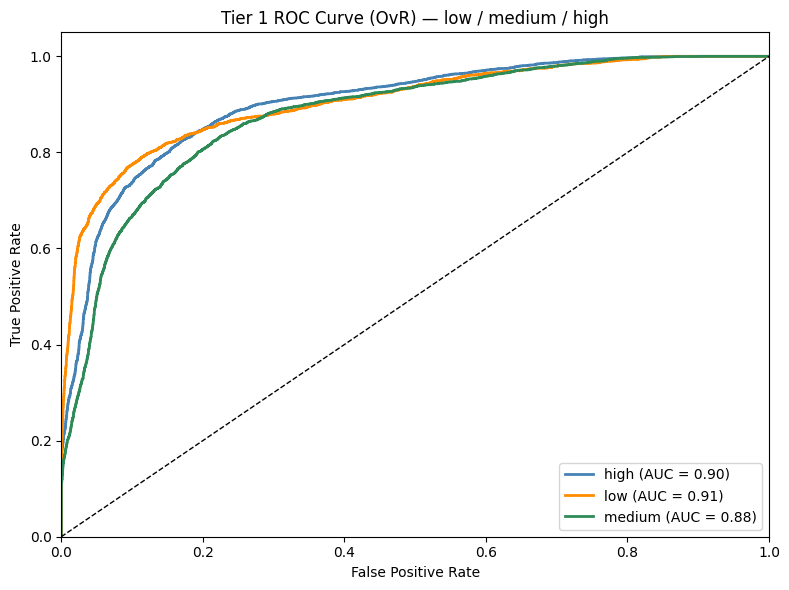

In [33]:
# ── ROC Curve: Tier 1 (multiclass OvR) ───────────────────────────────────────
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

# Binarize Tier 1 test labels
t1_classes = pipeline_tier1.classes_
y_t1_bin = label_binarize(y_t1_test, classes=t1_classes)
y_t1_probs = pipeline_tier1.predict_proba(X_t1_test)

plt.figure(figsize=(8, 6))
colors = ["steelblue", "darkorange", "seagreen"]

for i, (cls, color) in enumerate(zip(t1_classes, colors)):
    fpr, tpr, _ = roc_curve(y_t1_bin[:, i], y_t1_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, lw=2, label=f"{cls} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tier 1 ROC Curve (OvR) — low / medium / high")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

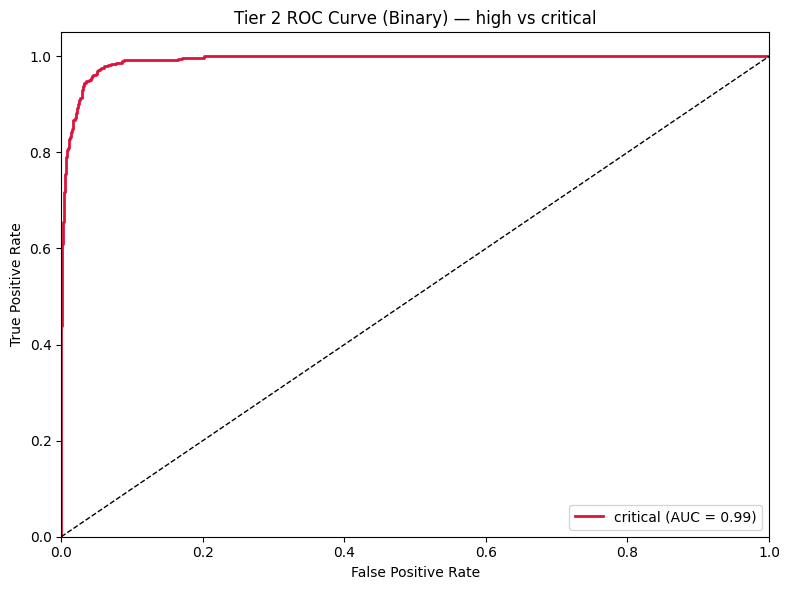

In [34]:
# ── ROC Curve: Tier 2 (binary: high vs critical) ─────────────────────────────
critical_idx = list(pipeline_tier2.classes_).index("critical")
y_t2_probs = pipeline_tier2.predict_proba(X_t2_test)[:, critical_idx]

fpr, tpr, _ = roc_curve(y_t2_test, y_t2_probs, pos_label="critical")
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color="crimson", lw=2, label=f"critical (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Tier 2 ROC Curve (Binary) — high vs critical")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [23]:
print(y_t2_test.value_counts())

# What do the critical probabilities actually look like?
critical_idx = list(pipeline_tier2.classes_).index("critical")
t2_probs = pipeline_tier2.predict_proba(X_t2_test)[:, critical_idx]

prob_df = pd.DataFrame({
    "true_label": y_t2_test.values,
    "critical_prob": t2_probs
})

print("\nCritical ticket probability distribution:")
print(prob_df[prob_df["true_label"] == "critical"]["critical_prob"].describe())

print("\nHigh ticket probability distribution:")
print(prob_df[prob_df["true_label"] == "high"]["critical_prob"].describe())

priority
high        4385
critical     383
Name: count, dtype: int64

Critical ticket probability distribution:
count    383.000000
mean       0.872773
std        0.271318
min        0.000341
25%        0.948427
50%        0.998211
75%        0.999924
max        1.000000
Name: critical_prob, dtype: float64

High ticket probability distribution:
count    4.385000e+03
mean     1.278907e-02
std      9.136080e-02
min      0.000000e+00
25%      1.525162e-10
50%      3.756400e-08
75%      8.793095e-06
max      9.995775e-01
Name: critical_prob, dtype: float64


In [24]:
print(df_tier2.groupby(["priority", "language"]).size())


priority  language
critical  de           1914
high      de          11008
          en          10917
dtype: int64
